# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HarshiniChebrolu/Flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

### Research question

Can observable content and recent search-performance signals be used to measure whether a content item is associated with a **down, stable, or up** trend direction, while using a validation design that avoids placing the same client in both training and test data?

### Decision supported

The analysis is intended to support **content-review prioritization**. It identifies measurable patterns that can help a content team decide which items may deserve earlier human review and which items can be monitored.

This is decision-support only. The model does not establish that a recommended action will cause future traffic, ranking, or performance improvement.

## 2. Data

The analysis uses the anonymized FlyRank content-refresh dataset available for this internship project.

The working dataset contains **30,000 content records and 44 columns**.

The analysis uses content-level search and performance signals, including fields describing search demand, competition, content characteristics, recent impressions, clicks, CTR, engagement, position, and related observable attributes.

The prediction target is `trend_direction`, with the observed classes representing **down, stable, and up**.

The following fields were excluded from predictive features:

- `trend_direction` — the target itself
- `trend_pct` — directly represents the observed outcome change
- `action` — outcome/recommendation-related field
- `action_score` — recommendation-related field
- `client_id` — reserved for grouped validation
- `content_id` — identifier
- `url` and `page_url` — identifiers/URLs
- `client_name` — client identifier

Rows without a usable `client_id` were excluded from the client-grouped validation analysis because a client-grouped split requires a valid group identifier.

The analysis is public-safe: identifiers and private client information are not used as predictive features or presented as business-specific findings.

## 3. Methodology

### Assumptions

The analysis treats the available content and recent search-performance fields as observable signals associated with the measured trend direction in the dataset.

The results are descriptive and directional. They should not be interpreted as causal evidence.

### Features

The model uses the available non-identifier, non-outcome fields after excluding the target and leakage-prone fields.

Numeric variables are median-imputed and standardized.

Categorical variables are imputed using the most frequent value and one-hot encoded.

### Label definition

The target is `trend_direction`.

The model evaluates the observed classes in the dataset: down, stable, and up.

### Model

The selected model is **Logistic Regression**.

It provides a simple and interpretable multiclass baseline for measuring whether the available signals contain useful information about the observed trend classes.

### Validation design

Two validation designs were examined:

1. A stratified 80/20 random split used in the earlier modeling stage.
2. A stricter 80/20 client-grouped split in which all observations from a client remain in only one partition.

The client-grouped split is used to test whether measured performance changes when the test clients were not represented in training.

The grouped validation produced 23,837 training rows from 25 clients and 6,163 test rows from 7 clients, with zero client overlap.

### Leakage checks

The audit explicitly excludes the target, outcome-related fields, and identifier fields from model features.

`client_id` is used only for creating the grouped validation split and is not used as a predictive feature.

## 4. Results (vs baseline)

The measured results show that validation design materially affects the reported performance.

| Validation design | Accuracy | Macro F1 |
|---|---:|---:|
| Random stratified split | 0.7570 | 0.6644 |
| Client-grouped split | 0.6568 | 0.5097 |

The random split produced higher measured performance. Under the stricter client-grouped validation, performance decreased to 0.6568 accuracy and 0.5097 macro F1.

This difference is important for interpretation: observations from the same client can be related, so a random row-level split may produce a more optimistic measurement than a split that keeps clients separated.

Therefore, the client-grouped result is the more relevant stress test for the question of performance on clients not represented in training.

The results measure predictive performance on this evaluated dataset. They do not establish performance on every future client or future dataset.

## 5. Limitations

This work has several important limitations.

1. The dataset represents the evaluated FlyRank internship dataset and may not represent every future client, content type, or search environment.

2. The model measures association with the observed `trend_direction` label. It does not establish causal relationships.

3. Performance changes substantially between random and client-grouped validation, showing that validation design matters.

4. The model should not be interpreted as predicting the behavior of a search engine or guaranteeing future traffic or ranking changes.

5. The action recommendations are based on observed signals and are intended for human review. They do not prove that applying a recommendation will improve performance.

6. The analysis uses the fields available in the dataset. Important real-world factors that are not represented in the data cannot be evaluated.

7. The grouped validation uses a single 80/20 group split, so the measured result should be treated as a validation measurement rather than a universal performance estimate.

## 6. Ranked recommendations

The action playbook converts observed signals into a human-review queue.

### 1. Prioritize items with negative observed trends for review

Items showing negative observed trends should receive earlier human review because the dataset provides an observable signal that their recent performance has declined.

### 2. Review CTR-related issues

The playbook identifies items where CTR-related signals indicate that a CTR-focused review may be appropriate.

Possible review areas include search-result presentation, title clarity, and alignment between the search intent and the page's visible result information.

### 3. Consider content refresh for items showing stronger deterioration signals

Items with stronger negative performance signals can be considered for content-refresh review.

The purpose is to identify candidates for human investigation, not to claim that refreshing a page will necessarily improve future performance.

### 4. Monitor items without a strong intervention signal

Items without a strong deterioration or CTR-review signal can remain in a monitoring queue so that teams can observe subsequent changes before taking action.

### Decision-support framing

The playbook produces three recommendation categories:

- `REFRESH`
- `CTR_FIX`
- `MONITOR`

Across the 30,000 evaluated rows, the observed recommendation counts were:

| Recommendation | Count |
|---|---:|
| MONITOR | 13,738 |
| CTR_FIX | 11,376 |
| REFRESH | 4,886 |

These are prioritization outputs from the evaluated dataset, not guarantees of future outcomes.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

,Validation design,Accuracy,Macro F1
0,Random stratified split,0.7570,0.6644
1,Client-grouped split,0.6568,0.5097


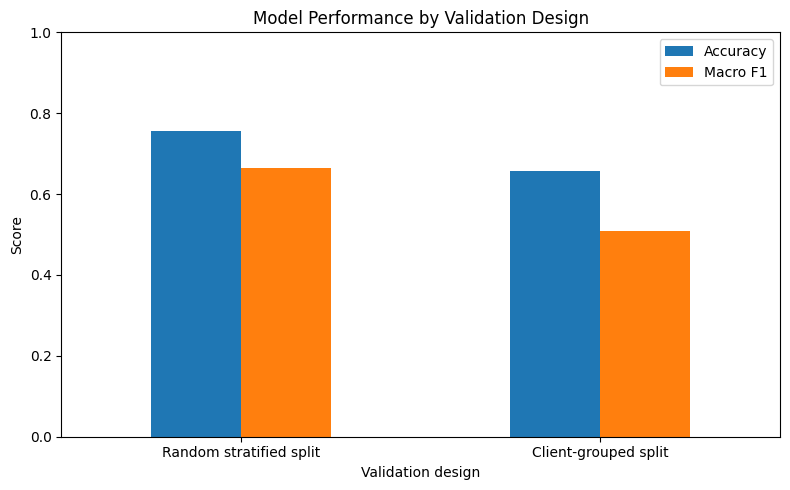

,Recommendation,Count
0,MONITOR,13738
1,CTR_FIX,11376
2,REFRESH,4886


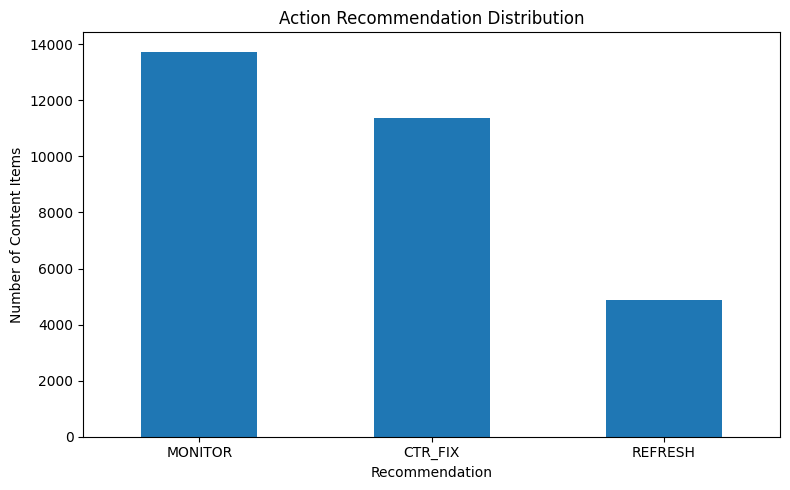

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Measured validation results from ML-09
results = pd.DataFrame({
    "Validation design": [
        "Random stratified split",
        "Client-grouped split"
    ],
    "Accuracy": [
        0.7570,
        0.6568
    ],
    "Macro F1": [
        0.6644,
        0.5097
    ]
})

display(results)

# Plot validation comparison
ax = results.set_index("Validation design")[["Accuracy", "Macro F1"]].plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Model Performance by Validation Design")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "validation_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ML-10 recommendation distribution
recommendations = pd.DataFrame({
    "Recommendation": ["MONITOR", "CTR_FIX", "REFRESH"],
    "Count": [13738, 11376, 4886]
})

display(recommendations)

ax = recommendations.set_index("Recommendation")["Count"].plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Action Recommendation Distribution")
ax.set_ylabel("Number of Content Items")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "recommendation_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Artifacts summary

The paper embeds two main quantitative artifacts:

1. **Validation comparison:** measured Accuracy and Macro F1 under random stratified and client-grouped validation.
2. **Recommendation distribution:** the number of evaluated content items assigned to MONITOR, CTR_FIX, and REFRESH by the ML-10 action playbook.

The artifacts are intended to make the methodology and results inspectable rather than relying only on narrative claims.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
